In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [7]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

cuda


In [4]:
cali = fetch_california_housing()
df = pd.DataFrame(cali.data, columns=cali.feature_names)
df['target'] = cali.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
data = torch.from_numpy(df.values).float().to(device)
data.shape

torch.Size([20640, 9])

In [14]:
X = data[:, :-1]
y = data[:, -1].reshape(-1, 1)
print(X)
print(y)
print(X.shape, y.shape)

tensor([[   8.3252,   41.0000,    6.9841,  ...,    2.5556,   37.8800,
         -122.2300],
        [   8.3014,   21.0000,    6.2381,  ...,    2.1098,   37.8600,
         -122.2200],
        [   7.2574,   52.0000,    8.2881,  ...,    2.8023,   37.8500,
         -122.2400],
        ...,
        [   1.7000,   17.0000,    5.2055,  ...,    2.3256,   39.4300,
         -121.2200],
        [   1.8672,   18.0000,    5.3295,  ...,    2.1232,   39.4300,
         -121.3200],
        [   2.3886,   16.0000,    5.2547,  ...,    2.6170,   39.3700,
         -121.2400]], device='cuda:0')
tensor([[4.5260],
        [3.5850],
        [3.5210],
        ...,
        [0.9230],
        [0.8470],
        [0.8940]], device='cuda:0')
torch.Size([20640, 8]) torch.Size([20640, 1])


In [21]:
n_epochs = 50000
learning_rate = 1e-3
print_interval = 500

In [23]:
model = nn.Linear(X.shape[-1], y.shape[-1]).to(device)
print(model)

Linear(in_features=8, out_features=1, bias=True)


In [24]:
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [25]:
for i in range(n_epochs):
    y_hat = model(X)
    loss = F.mse_loss(y_hat, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (i+1) % print_interval == 0:
        print(f'Epoch {i + 1}: loss={loss}')

Epoch 500: loss=503.1041564941406
Epoch 1000: loss=168.6646270751953
Epoch 1500: loss=72.46764373779297
Epoch 2000: loss=27.735198974609375
Epoch 2500: loss=13.497365951538086
Epoch 3000: loss=9.949807167053223
Epoch 3500: loss=8.517555236816406
Epoch 4000: loss=7.2694220542907715
Epoch 4500: loss=6.037622451782227
Epoch 5000: loss=4.887739181518555
Epoch 5500: loss=3.898087739944458
Epoch 6000: loss=3.1226682662963867
Epoch 6500: loss=2.569793462753296
Epoch 7000: loss=2.200037956237793
Epoch 7500: loss=1.9488515853881836
Epoch 8000: loss=1.759871006011963
Epoch 8500: loss=1.603916883468628
Epoch 9000: loss=1.4738491773605347
Epoch 9500: loss=1.36929452419281
Epoch 10000: loss=1.2870275974273682
Epoch 10500: loss=1.2195169925689697
Epoch 11000: loss=1.1576040983200073
Epoch 11500: loss=1.0939443111419678
Epoch 12000: loss=1.0250234603881836
Epoch 12500: loss=0.9511090517044067
Epoch 13000: loss=0.8751474022865295
Epoch 13500: loss=0.8017407059669495
Epoch 14000: loss=0.736212134361267

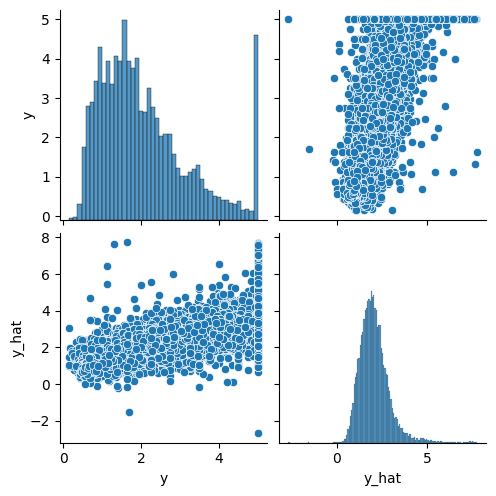

In [28]:
result_df = pd.DataFrame(torch.concat([y, y_hat], dim=1).cpu().detach_().numpy(), columns=['y', 'y_hat'])
sns.pairplot(result_df)
plt.show()

In [30]:
print(y)
print(y_hat)

tensor([[4.5260],
        [3.5850],
        [3.5210],
        ...,
        [0.9230],
        [0.8470],
        [0.8940]], device='cuda:0')
tensor([[4.1016],
        [3.8916],
        [3.5355],
        ...,
        [0.6093],
        [0.7340],
        [0.9805]], device='cuda:0', grad_fn=<AddmmBackward0>)


In [33]:
np_y = y.cpu().detach_().numpy().squeeze()
np_y_hat = y_hat.cpu().detach_().numpy().squeeze()
print(np.corrcoef(np_y, np_y_hat))

[[1.         0.74141974]
 [0.74141974 1.        ]]


In [34]:
del model
torch.cuda.empty_cache()